# Parameter Impact on the BH-BH Merger Rate

For each **parameter family** (e.g. common-envelope efficiency, stellar evolution tracks), this notebook shows — in one panel per family — how the local BH-BH merger rate changes across the model variations reported in the isolated-binary-evolution literature.

**Figure layout:**  
- One panel per parameter family.  
- One row per study that varies that parameter.  
- One scatter point per named sub-model of that study, connected by a thin horizontal line.  
- Fiducial / reference sub-model highlighted with a gold star (★).  
- Where a sub-model internally spans a range (multiple rate rows, e.g. metallicity bins), a shaded error bar shows [min, max].  

**Data source:** `Data_Mandel_and_Broekgaarden_2026/isolated-binary-evolution.csv`

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rc, rcParams

warnings.filterwarnings('ignore')

# ── Match the style of plot_rates.py ────────────────────────────────────────
rc("font", family="serif", weight="bold")
rc("text", usetex=True)
rcParams["text.latex.preamble"] = r"\usepackage{amsmath}" + "\n" + r"\boldmath"
rc("axes", linewidth=1.8)
rcParams.update({
    "xtick.major.size": 10, "ytick.major.size": 10,
    "xtick.minor.size": 6,  "ytick.minor.size": 6,
    "font.weight": "bold",
})

FONTSIZE       = 16
IBE_COLOR      = "#e07830"   # warm orange used for isolated-binary-evolution
FIDUCIAL_COLOR = "#f1c40f"   # gold for fiducial / reference sub-model
FIDUCIAL_EDGE  = "#b7950b"

_LATEX_ESCAPES = str.maketrans({"&": r"\&", "%": r"\%", "#": r"\#"})
def _tex(s: str) -> str:
    return s.translate(_LATEX_ESCAPES)

In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
DATA_DIR = Path("../Data_Mandel_and_Broekgaarden_2026")

# The relationships CSV drives this figure — BH-BH rates are embedded per submodel.
rels = pd.read_csv(DATA_DIR / "isolated-binary-evolution_relationships.csv")
rels["from_rate"] = pd.to_numeric(rels["from_rate_Gpc3yr"], errors="coerce")
rels["to_rate"]   = pd.to_numeric(rels["to_rate_Gpc3yr"],   errors="coerce")

# Pull publication year from the main CSV for within-panel sort order
_year_map = (
    pd.read_csv(DATA_DIR / "isolated-binary-evolution.csv", dtype=str).fillna("")
    .drop_duplicates("study_key")
    .set_index("study_key")["year"]
    .apply(pd.to_numeric, errors="coerce")
)
rels["year"] = rels["study_key"].map(_year_map)

print(f"Relationships loaded: {len(rels)} rows, {rels['study_key'].nunique()} studies")
print(f"Unique parameters:    {sorted(rels['parameter'].unique())}")

Relationships loaded: 263 rows, 16 studies
Unique parameters:    ['$T_{eff}$', 'BH_spin_coupling', 'BPASS_rate_method', 'CE optimistic/pessimistic', 'CE_criterion', 'CE_pessimistic', 'HG_MT_stability', 'IMF', 'MT_timescale_switch', 'PISN_mass_threshold', 'SFRD_model', 'alpha_CE', 'alpha_CE_lambda', 'beta_MT', 'convection_criterion', 'f_WR', 'f_core', 'f_disk', 'fmix', 'gamma_AM', 'initial_binary_distributions', 'kick_prescription', 'max_stellar_radius', 'multi-parameter', 'q_crit', 'sigma_BH', 'sigma_kick', 'stellar_uncertainty', 'supernova_engine', 'zeta_stability']


In [3]:
# ── Map each specific parameter → display panel ──────────────────────────────
# Studies that vary multiple parameters will appear in multiple panels.
PARAMETER_TO_PANEL = {
    # CE efficiency
    "alpha_CE":              r"CE efficiency ($\alpha_{\rm CE}$)",
    "alpha_CE_lambda":       r"CE efficiency ($\alpha_{\rm CE}$)",
    "gamma_CE":              r"CE efficiency ($\alpha_{\rm CE}$)",
    # CE criterion / pessimistic vs optimistic
    "CE_pessimistic":        r"CE criterion \& pessimistic/optimistic",
    "CE_criterion":          r"CE criterion \& pessimistic/optimistic",
    "HG_CE_treatment":       r"CE criterion \& pessimistic/optimistic",
    "CE optimistic/pessimistic": r"CE criterion \& pessimistic/optimistic",
    # MT efficiency
    "beta_MT":               r"MT efficiency ($\beta$)",
    # MT stability
    "caseBB_stability":      r"MT stability",
    "zeta_stability":        r"MT stability",
    "RLOF_criterion":        r"MT stability",
    "HG_MT_stability":       r"MT stability",
    "MT_timescale_switch":   r"MT stability",
    "q_crit":                r"MT stability",
    # Natal kicks
    "sigma_kick":            r"Natal kicks ($\sigma_{\rm kick}$)",
    "sigma_BH":              r"Natal kicks ($\sigma_{\rm kick}$)",
    "kick_prescription":     r"Natal kicks ($\sigma_{\rm kick}$)",
    # Remnant mass / PISN
    "supernova_engine":      r"Remnant mass prescription",
    "max_NS_mass":           r"Remnant mass prescription",
    "PISN":                  r"Remnant mass prescription",
    "PISN_mass_threshold":   r"Remnant mass prescription",
    "fmix":                  r"Remnant mass prescription",
    "f_core":                r"Remnant mass prescription",
    # Stellar tracks
    "max_stellar_radius":    r"Stellar evolution tracks",
    "convection_criterion":  r"Stellar evolution tracks",
    "BPASS_rate_method":     r"Stellar evolution tracks",
    "stellar_uncertainty":   r"Stellar evolution tracks",
    # SFH
    "SFRD_model":            r"Star formation history",
    "SFR_model":             r"Star formation history",
    # Initial conditions
    "initial_binary_distributions": r"Initial conditions",
    "IMF":                   r"Initial conditions",
    # Angular momentum / winds
    "BH_spin_coupling":      r"Angular momentum \& winds",
    "f_WR":                  r"Angular momentum \& winds",
    "gamma_AM":              r"Angular momentum \& winds",
    "f_disk":                r"Angular momentum \& winds",
    # Multi-parameter
    "multi-parameter":       r"Multi-parameter",
}

rels["panel"] = rels["parameter"].map(PARAMETER_TO_PANEL).fillna("Other")

# Build a flat table: one row per unique (panel, study_key, submodel) point.
# Each relationship row contributes its two endpoints; duplicates are removed.
_from = rels[["study_key", "label", "year", "panel",
              "from_submodel", "from_rate"]].rename(
    columns={"from_submodel": "submodel", "from_rate": "rate"})
_to   = rels[["study_key", "label", "year", "panel",
              "to_submodel", "to_rate"]].rename(
    columns={"to_submodel": "submodel", "to_rate": "rate"})

pts = (pd.concat([_from, _to], ignore_index=True)
         .drop_duplicates(subset=["panel", "study_key", "submodel"])
         .copy())
pts["is_fiducial"] = (pts["submodel"].str.lower().str.contains("fiducial") |
                      (pts["submodel"] == "ref"))

# Build a flat table of edges: one row per relationship, carrying its panel.
# Each edge is drawn as its own line segment between its two submodels'
# rates, so a study with several disjoint "chains" (e.g. Boesky's alpha_CE
# sweep repeated at 3 fixed beta_MT values) shows 3 separate segments
# rather than one misleading min-to-max bar across all of them.
edges = (rels[["study_key", "panel", "from_submodel", "to_submodel",
               "from_rate", "to_rate"]]
           .dropna(subset=["from_rate", "to_rate"])
           .copy())

print(f"Total (panel, study, submodel) points: {len(pts)}")
print(f"Edges with both rates available:       {len(edges)}")
print(f"Panels: {sorted(pts['panel'].unique())}")
pts.head(8)

Total (panel, study, submodel) points: 288
Edges with both rates available:       239
Panels: ['Angular momentum \\& winds', 'CE criterion \\& pessimistic/optimistic', 'CE efficiency ($\\alpha_{\\rm CE}$)', 'Initial conditions', 'MT efficiency ($\\beta$)', 'MT stability', 'Multi-parameter', 'Natal kicks ($\\sigma_{\\rm kick}$)', 'Other', 'Remnant mass prescription', 'Star formation history', 'Stellar evolution tracks']


,study_key,label,year,panel,submodel,rate,is_fiducial
0,Sgalletta_2025_SEVN,Sgalletta et al. (2025),2025.0,CE efficiency ($\alpha_{\rm CE}$),Sgalletta_alpha_0_5,255.6,False
1,Sgalletta_2025_SEVN,Sgalletta et al. (2025),2025.0,CE efficiency ($\alpha_{\rm CE}$),Sgalletta_alpha_1,296.4,False
2,Sgalletta_2025_SEVN,Sgalletta et al. (2025),2025.0,CE efficiency ($\alpha_{\rm CE}$),Sgalletta_alpha_3,203.3,False
3,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017.0,CE efficiency ($\alpha_{\rm CE}$),D0.02,145.0,False
4,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017.0,CE efficiency ($\alpha_{\rm CE}$),D (fiducial),NaN,True
5,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017.0,Remnant mass prescription,D (fiducial),NaN,True
6,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017.0,CE criterion \& pessimistic/optimistic,D (fiducial),NaN,True
7,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017.0,Natal kicks ($\sigma_{\rm kick}$),D (fiducial),NaN,True


In [4]:
# ── Build panel structure ────────────────────────────────────────────────────
PANEL_ORDER = [
    r"CE efficiency ($\alpha_{\rm CE}$)",
    r"CE criterion \& pessimistic/optimistic",
    r"MT efficiency ($\beta$)",
    r"MT stability",
    r"Natal kicks ($\sigma_{\rm kick}$)",
    r"Remnant mass prescription",
    r"Stellar evolution tracks",
    r"Star formation history",
    r"Initial conditions",
    r"Angular momentum \& winds",
    r"Multi-parameter",
]

panels = {}
for panel_name in PANEL_ORDER:
    panel_pts = pts[pts["panel"] == panel_name]
    if panel_pts.empty:
        continue
    panel_edges = edges[edges["panel"] == panel_name]
    studies = (panel_pts.drop_duplicates("study_key")
                        .sort_values("year")["study_key"].tolist())
    panels[panel_name] = {"studies": studies, "pts": panel_pts, "edges": panel_edges}

print("Panels and studies:")
for g, p in panels.items():
    print(f"  [{g}]:")
    for sk in p["studies"]:
        n_sub = p["pts"][p["pts"]["study_key"] == sk]["submodel"].nunique()
        n_edg = (p["edges"]["study_key"] == sk).sum()
        print(f"    {sk}  ({n_sub} submodels, {n_edg} edges)")

Panels and studies:
  [CE efficiency ($\alpha_{\rm CE}$)]:
    Mapelli_2017_MOBSE  (3 submodels, 0 edges)
    Boesky_2024_COMPAS  (12 submodels, 9 edges)
    Sgalletta_2025_SEVN  (4 submodels, 3 edges)
    Li_2025_MOBSE  (3 submodels, 2 edges)
  [CE criterion \& pessimistic/optimistic]:
    Mapelli_2017_MOBSE  (2 submodels, 0 edges)
    Neijssel_2019_COMPAS  (38 submodels, 19 edges)
    Olejak_2021_Startrack  (2 submodels, 1 edges)
    Olejak_2022_Startrack  (12 submodels, 6 edges)
  [MT efficiency ($\beta$)]:
    Dorozsmai_2022_SeBa  (16 submodels, 8 edges)
    vanSon_2022_SMT_COMPAS  (5 submodels, 4 edges)
    Boesky_2024_COMPAS  (12 submodels, 8 edges)
  [MT stability]:
    Chruslinska_2019_StarTrack  (2 submodels, 1 edges)
    Olejak_2021_Startrack  (2 submodels, 1 edges)
    Dorozsmai_2022_SeBa  (16 submodels, 8 edges)
    vanSon_2022_SMT_COMPAS  (5 submodels, 4 edges)
    Li_2025_MOBSE  (2 submodels, 1 edges)
  [Natal kicks ($\sigma_{\rm kick}$)]:
    Mapelli_2017_MOBSE  (2 submo

In [5]:
# ── Drawing helpers ───────────────────────────────────────────────────────────

def draw_study_in_panel(ax, study_pts, study_edges, y, color=IBE_COLOR,
                        fiducial_color=FIDUCIAL_COLOR, fiducial_edge=FIDUCIAL_EDGE):
    sub = study_pts.drop_duplicates("submodel").dropna(subset=["rate"])
    if sub.empty:
        return
    # One line segment per relationship (edge) directly connecting the two
    # submodels it relates — not a single min-to-max bar across all points.
    for _, erow in study_edges.iterrows():
        ax.plot([erow["from_rate"], erow["to_rate"]], [y, y],
                color=color, lw=3.0, zorder=3, alpha=0.55, solid_capstyle="butt")
    for _, row in sub.iterrows():
        r = row["rate"]
        if row["is_fiducial"]:
            ax.scatter(r, y, s=280, marker="*",
                       c=fiducial_color, edgecolors=fiducial_edge,
                       linewidths=1.2, zorder=100)
        else:
            ax.scatter(r, y, s=50, marker="|",
                       c=[color], edgecolors="k",
                       linewidths=1.7, zorder=50)


def style_panel(ax, xmin, xmax):
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_yticks([])
    ax.tick_params(which="major", length=8, width=1.2, labelsize=FONTSIZE - 2)
    ax.tick_params(which="minor", length=4, width=1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    for xv in [1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4]:
        if xmin <= xv <= xmax:
            ax.axvline(xv, lw=0.8, color="0.75", ls=":", zorder=0)

In [6]:
# ── Diagnostic: which studies appear in which panels ─────────────────────────
summary = (pts.drop_duplicates(["panel","study_key"])
              .sort_values(["panel","year"])[["panel","study_key","label","year"]]
              .reset_index(drop=True))
display(summary)

,panel,study_key,label,year
0,Angular momentum \& winds,Belczynski_2020_StarTrack,Belczynski et al. (2020),2020.0
1,Angular momentum \& winds,Dorozsmai_2022_SeBa,Dorozsmai \& Toonen (2022),2022.0
2,Angular momentum \& winds,vanSon_2022_SMT_COMPAS,van Son (2022) SMT only,2022.0
3,Angular momentum \& winds,Li_2025_MOBSE,Li et al. (2025),2025.0
4,CE criterion \& pessimistic/optimistic,Mapelli_2017_MOBSE,Mapelli et al. (2017),2017.0
5,CE criterion \& pessimistic/optimistic,Neijssel_2019_COMPAS,Neijssel et al. (2019),2019.0
6,CE criterion \& pessimistic/optimistic,Olejak_2021_Startrack,Olejak et al. (2021),2021.0
7,CE criterion \& pessimistic/optimistic,Olejak_2022_Startrack,Olejak et al. (2022),2022.0
8,CE efficiency ($\alpha_{\rm CE}$),Mapelli_2017_MOBSE,Mapelli et al. (2017),2017.0
9,CE efficiency ($\alpha_{\rm CE}$),Boesky_2024_COMPAS,Boesky et al. (2024),2024.0


Saved: parameter_impact_BHBH.pdf / .png


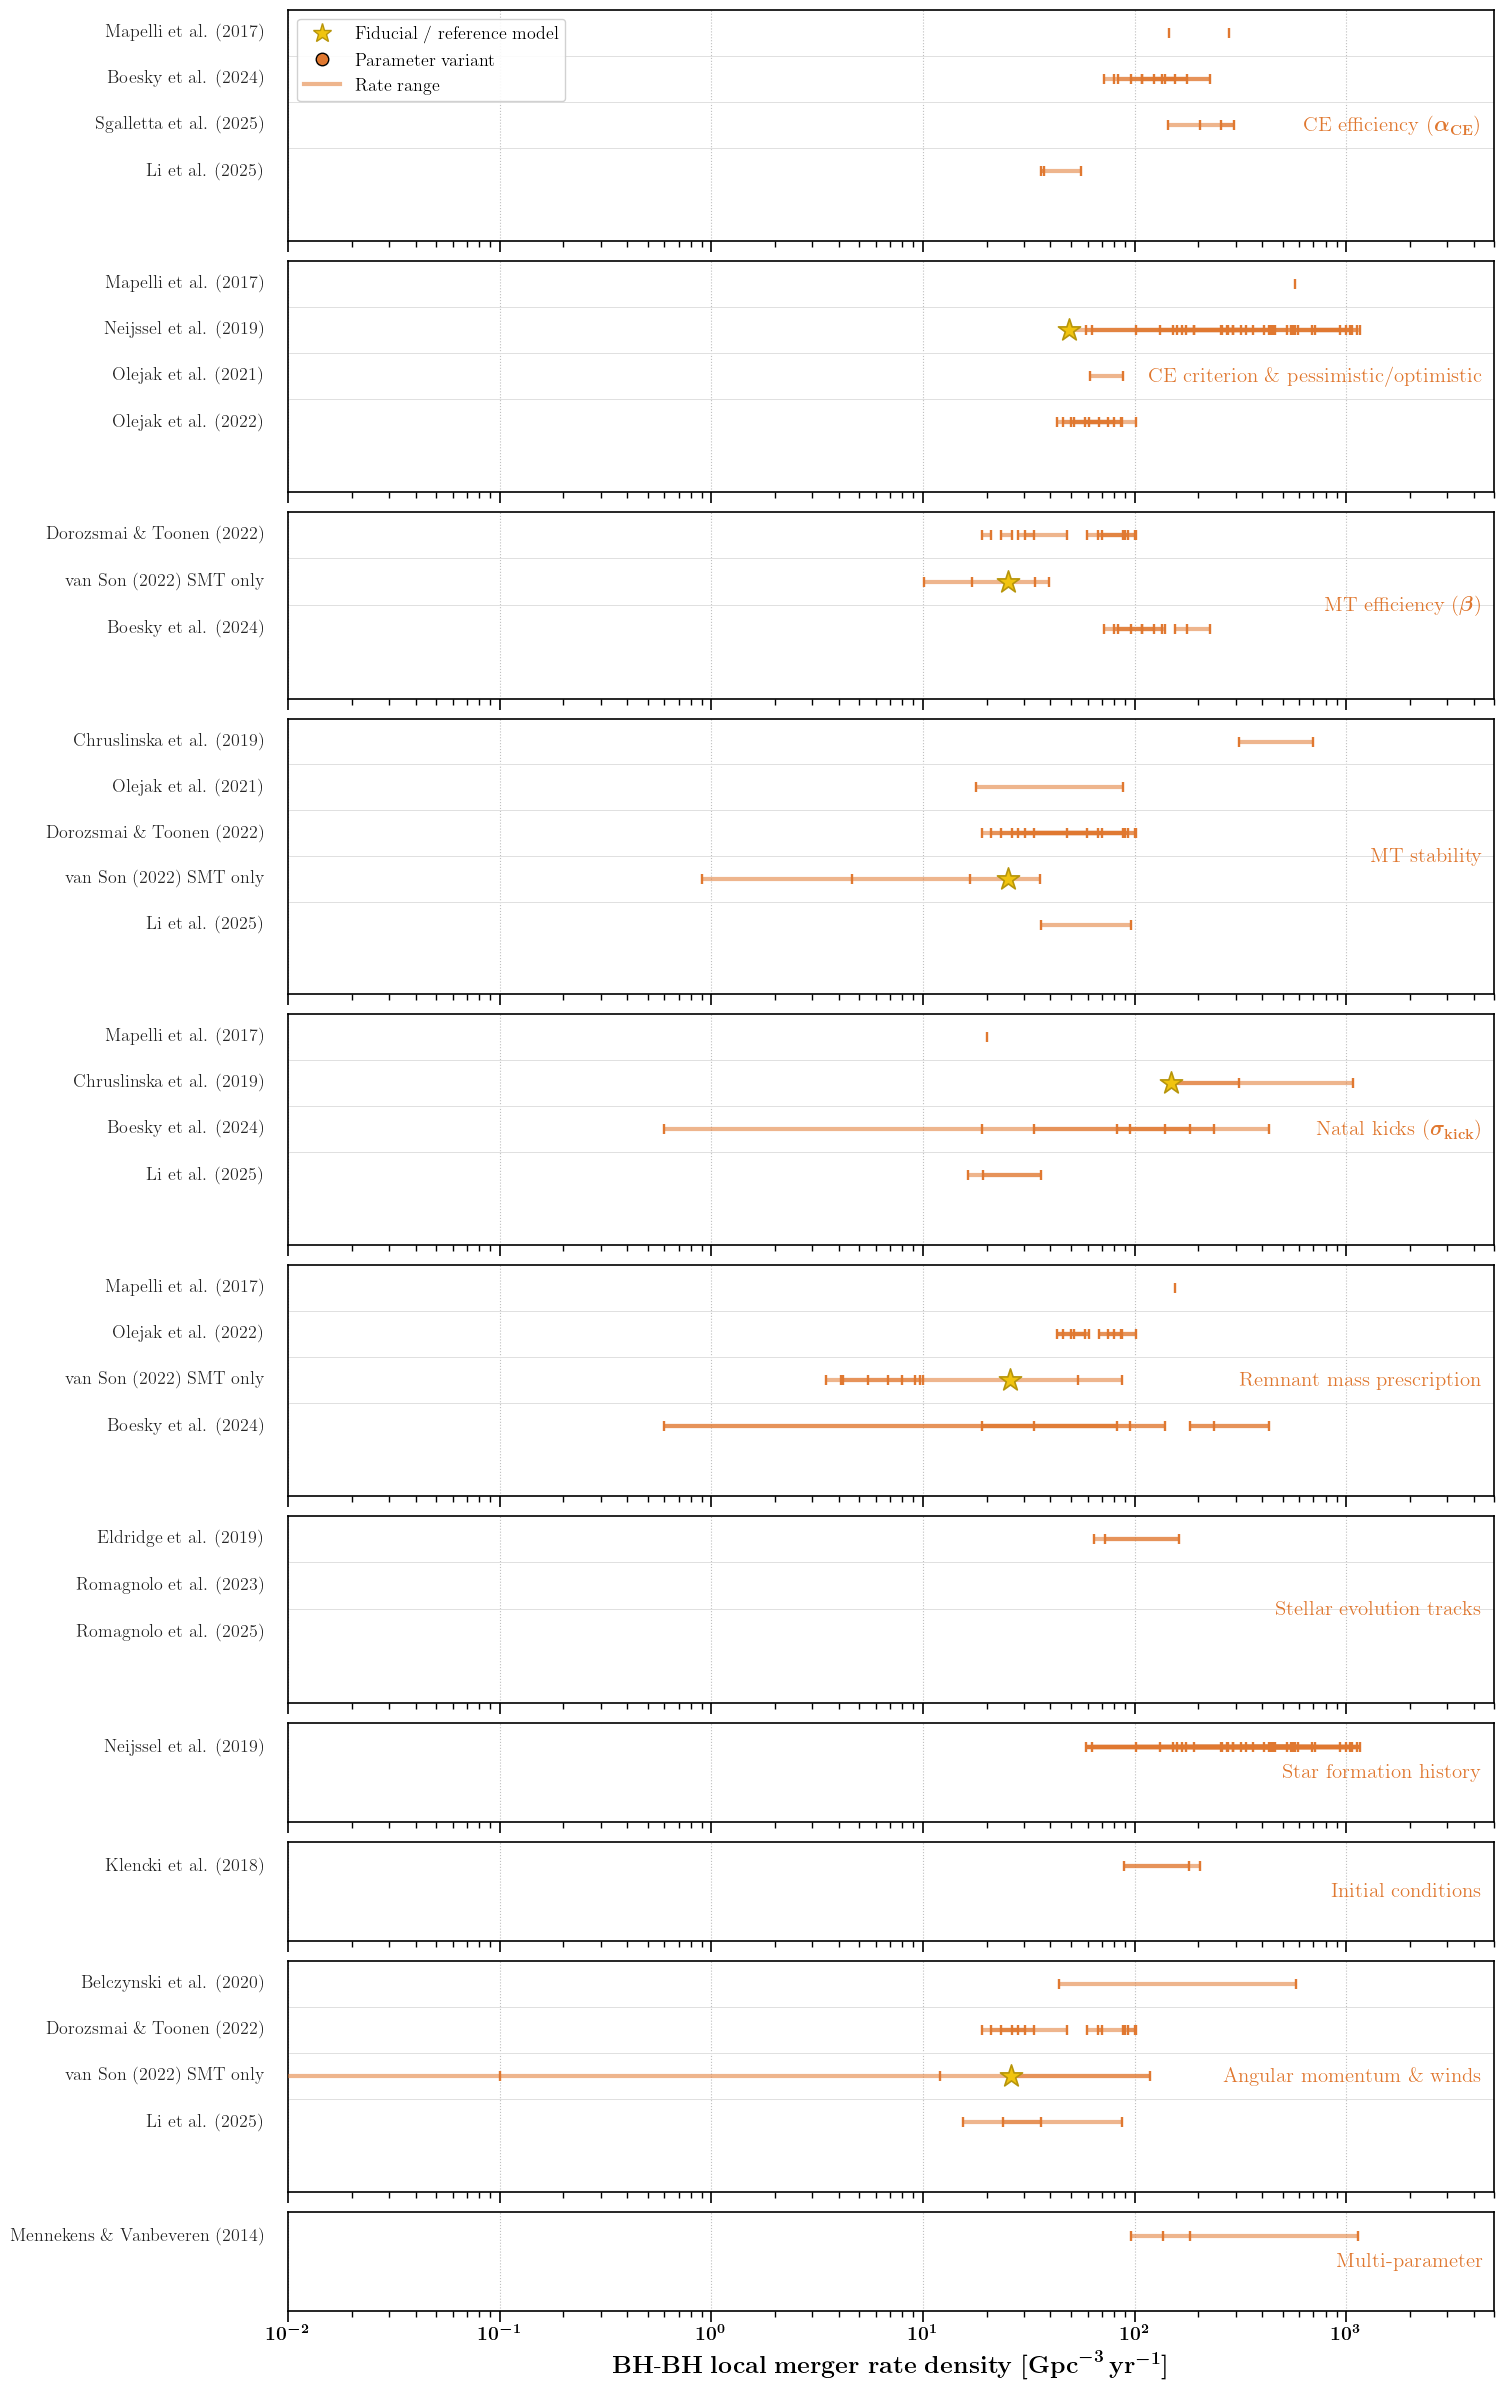

In [7]:
# ── Main figure ───────────────────────────────────────────────────────────────
from matplotlib.transforms import blended_transform_factory

XMIN, XMAX     = 1e-2, 5e3
FIG_WIDTH      = 18
ROW_H          = 0.44
PANEL_HDR_H    = 0.55
GAP_H          = 0.20
TOP_MARGIN     = 0.70
BOT_MARGIN     = 0.80
LABEL_FONTSIZE = FONTSIZE - 3

panel_heights = [len(panels[g]["studies"]) * ROW_H + PANEL_HDR_H for g in panels]
total_h = sum(panel_heights) + (len(panels) - 1) * GAP_H + TOP_MARGIN + BOT_MARGIN

fig = plt.figure(figsize=(FIG_WIDTH, total_h))

gs_heights = []
for i, h in enumerate(panel_heights):
    gs_heights.append(h)
    if i < len(panels) - 1:
        gs_heights.append(GAP_H)

gs = gridspec.GridSpec(
    nrows=len(gs_heights), ncols=1,
    height_ratios=gs_heights,
    left=0.30, right=0.97,
    top=1 - TOP_MARGIN / total_h,
    bottom=BOT_MARGIN / total_h,
    hspace=0,
)

axes = []
for panel_idx, (panel_name, panel) in enumerate(panels.items()):
    ax = fig.add_subplot(gs[panel_idx * 2, 0])
    style_panel(ax, XMIN, XMAX)
    axes.append(ax)

    studies   = panel["studies"]
    n_studies = len(studies)
    ax.set_ylim(-n_studies - 0.5, 0.5)

    trans_label = blended_transform_factory(ax.transAxes, ax.transData)

    for study_idx, sk in enumerate(studies):
        y           = -study_idx
        study_pts   = panel["pts"][panel["pts"]["study_key"] == sk]
        study_edges = panel["edges"][panel["edges"]["study_key"] == sk]

        draw_study_in_panel(ax, study_pts, study_edges, y)

        # Labels in the relationships CSV are already LaTeX-formatted (e.g. \&)
        label_text = study_pts["label"].iloc[0]
        ax.text(-0.02, y, label_text,
                ha="right", va="center",
                fontsize=LABEL_FONTSIZE, color="0.15",
                transform=trans_label)

        if study_idx < n_studies - 1:
            ax.axhline(-study_idx - 0.5, color="0.88", lw=0.7, zorder=0)

    ax.text(0.99, 0.50, panel_name,
            ha="right", va="center",
            fontsize=FONTSIZE - 1, color=IBE_COLOR, fontweight="bold",
            transform=ax.transAxes)

    if panel_idx < len(panels) - 1:
        ax.tick_params(labelbottom=False)

axes[-1].set_xlabel(
    r"$\mathbf{BH\text{-}BH\ local\ merger\ rate\ density}\ [\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$",
    fontsize=FONTSIZE + 2, labelpad=6,
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor=FIDUCIAL_COLOR,
           markeredgecolor=FIDUCIAL_EDGE, markersize=14, label="Fiducial / reference model"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=IBE_COLOR,
           markeredgecolor="k", markersize=9, label="Parameter variant"),
    Line2D([0],[0], color=IBE_COLOR, lw=3, alpha=0.55, label="Rate range"),
]
axes[0].legend(handles=legend_elements, loc="upper left",
               fontsize=FONTSIZE - 3, framealpha=0.9, edgecolor="0.8")

plt.savefig("parameter_impact_BHBH.pdf", bbox_inches="tight", dpi=200)
plt.savefig("parameter_impact_BHBH.png", bbox_inches="tight", dpi=200)
print("Saved: parameter_impact_BHBH.pdf / .png")
plt.show()

In [8]:
# ── Optional: per-panel close-up figures ─────────────────────────────────────

def make_single_panel(panel_name, save=False):
    if panel_name not in panels:
        print(f"Panel not found: {panel_name}")
        return
    panel    = panels[panel_name]
    studies  = panel["studies"]
    n_studies = len(studies)

    fig_h = n_studies * ROW_H + 1.5
    fig, ax = plt.subplots(figsize=(FIG_WIDTH * 0.7, fig_h))
    style_panel(ax, XMIN, XMAX)
    ax.set_ylim(-n_studies - 0.5, 0.5)

    from matplotlib.transforms import blended_transform_factory
    trans_label = blended_transform_factory(ax.transAxes, ax.transData)

    for study_idx, sk in enumerate(studies):
        y           = -study_idx
        study_pts   = panel["pts"][panel["pts"]["study_key"] == sk]
        study_edges = panel["edges"][panel["edges"]["study_key"] == sk]
        draw_study_in_panel(ax, study_pts, study_edges, y)
        label_text = study_pts["label"].iloc[0]
        ax.text(-0.02, y, label_text, ha="right", va="center",
                fontsize=LABEL_FONTSIZE, color="0.15", transform=trans_label)
        ax.axhline(-study_idx - 0.5, color="0.88", lw=0.7, zorder=0)

    ax.set_title(panel_name, fontsize=FONTSIZE + 2, color=IBE_COLOR, pad=8)
    ax.set_xlabel(
        r"$\mathbf{BH\text{-}BH\ merger\ rate}\ [\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$",
        fontsize=FONTSIZE,
    )
    plt.tight_layout()
    if save:
        import re
        slug = re.sub(r"[^\w]", "_", panel_name).strip("_").lower()
        plt.savefig(f"parameter_impact_BHBH_{slug}.pdf", bbox_inches="tight", dpi=200)
        plt.savefig(f"parameter_impact_BHBH_{slug}.png", bbox_inches="tight", dpi=200)
    plt.show()


# ── Uncomment any of these to get standalone panel figures: ─────────────────
# make_single_panel(r"CE efficiency ($\alpha_{\rm CE}$)", save=True)
# make_single_panel(r"MT efficiency ($\beta$)", save=True)
# make_single_panel(r"Natal kicks ($\sigma_{\rm kick}$)", save=True)

In [9]:
# ── Quick lookup: submodels for one study across all panels ──────────────────
STUDY_KEY = "Broekgaarden_COMPAS"   # change to any study_key

print(f"Submodels for {STUDY_KEY} (by panel):")
show = (pts[pts["study_key"] == STUDY_KEY]
          [["panel","submodel","rate","is_fiducial"]]
          .sort_values(["panel","rate"]))
pd.set_option("display.max_colwidth", 80)
display(show)

Submodels for Broekgaarden_COMPAS (by panel):


,panel,submodel,rate,is_fiducial
